# 01. Data Collection & Cleaning — SpaceX Falcon 9 Landing Prediction

## Introduction

This notebook covers the **end-to-end data acquisition and preprocessing pipeline** for the SpaceX Falcon 9 first-stage landing prediction project.

### Business Context

SpaceX advertises Falcon 9 rocket launches at **$62 million** per launch, while competitors charge upward of **$165 million**. The key cost advantage comes from SpaceX's ability to **reuse the first-stage booster**. If we can predict whether the first stage will land successfully, we can estimate the true cost of a launch — critical intelligence for any competitor bidding against SpaceX.

### Notebook Objectives

1. **Collect launch data** from the SpaceX REST API and enrich it with booster, payload, and landing metadata.
2. **Scrape historical records** from Wikipedia as a secondary validation source.
3. **Clean, filter, and engineer** the dataset into a machine-learning-ready format.
4. **Create the binary classification label** (`Class`): `1` = successful landing, `0` = unsuccessful landing.

### Why This Step Matters

> *"Garbage in, garbage out."* The quality of any predictive model is fundamentally bounded by the quality of its input data. This notebook ensures our downstream EDA and ML models are built on a solid, reproducible foundation.

---


## Imports & Configuration

We import the core scientific Python stack and configure display options for clean, readable outputs throughout the notebook.


In [1]:
import requests
import pandas as pd
import numpy as np
import datetime
import re
import unicodedata
from bs4 import BeautifulSoup

# ------------------------------------------------------------------
# Pandas display configuration
# ------------------------------------------------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 120)

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
np.random.seed(42)

print("All libraries loaded successfully.")
print(f"   Pandas version : {pd.__version__}")
print(f"   NumPy version  : {np.__version__}")


All libraries loaded successfully.
   Pandas version : 3.0.1
   NumPy version  : 2.4.4


---

## Part 1 — Data Collection via SpaceX REST API

### Overview

The SpaceX API (`spacexdata.com/v4`) provides granular launch records. However, the raw payload contains only **foreign keys** (rocket IDs, payload IDs, launchpad IDs). We must perform **secondary API calls** to resolve these IDs into human-readable features such as booster name, payload mass, orbit type, and landing outcome.

### Methodology

1. Query the main `/launches/past` endpoint.
2. Normalize the JSON response into a Pandas DataFrame.
3. Enrich each launch record by calling subsidiary endpoints (`/rockets`, `/payloads`, `/launchpads`, `/cores`).
4. Assemble a unified, analysis-ready dataset.


### 1.1 Primary API Request

We fetch all historical launch records and verify the HTTP status.


In [2]:
# ------------------------------------------------------------------
# Primary endpoint — all past launches
# ------------------------------------------------------------------
spacex_url = "https://api.spacexdata.com/v4/launches/past"

response = requests.get(spacex_url)
print(f"HTTP Status Code: {response.status_code}")

# For reproducibility, IBM provides a static snapshot:
static_json_url = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json"
)

# Parse JSON and flatten into a DataFrame
data = response.json()
data = pd.json_normalize(data)

print(f"Raw dataset shape: {data.shape}")
data.head(2)


HTTP Status Code: 200
Raw dataset shape: (187, 43)


,static_fire_date_utc,static_fire_date_unix,net,window,rocket,success,failures,details,crew,ships,capsules,payloads,launchpad,flight_number,name,date_utc,date_unix,date_local,date_precision,upcoming,cores,auto_update,tbd,launch_library_id,id,fairings.reused,fairings.recovery_attempt,fairings.recovered,fairings.ships,links.patch.small,links.patch.large,links.reddit.campaign,links.reddit.launch,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 33, 'altitude': None, 'reason': 'merlin engine failure'}]",Engine failure at 33 seconds and loss of vehicle,[],[],[],[5eb0e4b5b6c3bb0006eeb1e1],5e9e4502f5090995de566f86,1,FalconSat,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",True,False,NaN,5eb87cd9ffd86e000604b32a,False,False,False,[],https://images2.imgbox.com/94/f2/NN6Ph45r_o.png,https://images2.imgbox.com/5b/02/QcxHUb5V_o.png,NaN,NaN,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html,https://en.wikipedia.org/wiki/DemoSat,NaN
1,NaN,NaN,False,0.0,5e9d0d95eda69955f709d1eb,False,"[{'time': 301, 'altitude': 289, 'reason': 'harmonic oscillation leading to premature engine shutdown'}]","Successful first stage burn and transition to second stage, maximum altitude 289 km, Premature engine shutdown at T+7 min 30 s, Failed to reach orbit, Failed to recover first stage",[],[],[],[5eb0e4b6b6c3bb0006eeb1e2],5e9e4502f5090995de566f86,2,DemoSat,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",True,False,NaN,5eb87cdaffd86e000604b32b,False,False,False,[],https://images2.imgbox.com/f9/4a/ZboXReNb_o.png,https://images2.imgbox.com/80/a2/bkWotCIS_o.png,NaN,NaN,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-rocket-fails-reach-orbit.html,https://en.wikipedia.org/wiki/DemoSat,NaN


### 1.2 Feature Selection & Pre-filtering

The raw DataFrame contains 30+ columns, many of which are nested metadata or irrelevant for landing prediction. We keep only the identifiers needed for enrichment plus `flight_number` and `date_utc`.

We also apply two critical filters:
- **Single-core launches only** — Falcon Heavy and multi-core configurations are excluded.
- **Single-payload launches only** — simplifies payload mass attribution.
- **Date cutoff** — restrict to launches before 2020-11-13 for consistency with the IBM course baseline.


In [3]:
# ------------------------------------------------------------------
# Select relevant columns
# ------------------------------------------------------------------
data = data[['rocket', 'payloads', 'launchpad', 'cores',
             'flight_number', 'date_utc']]

# Filter: single-core and single-payload launches only
data = data[data['cores'].map(len) == 1]
data = data[data['payloads'].map(len) == 1]

# Unpack the single-element lists
data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])

# Parse UTC date and apply cutoff
data['date'] = pd.to_datetime(data['date_utc']).dt.date
data = data[data['date'] <= datetime.date(2020, 11, 13)]

print(f"Filtered dataset shape: {data.shape}")
data.head()


Filtered dataset shape: (94, 7)


,rocket,payloads,launchpad,cores,flight_number,date_utc,date
0,5e9d0d95eda69955f709d1eb,5eb0e4b5b6c3bb0006eeb1e1,5e9e4502f5090995de566f86,"{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",1,2006-03-24T22:30:00.000Z,2006-03-24
1,5e9d0d95eda69955f709d1eb,5eb0e4b6b6c3bb0006eeb1e2,5e9e4502f5090995de566f86,"{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",2,2007-03-21T01:10:00.000Z,2007-03-21
3,5e9d0d95eda69955f709d1eb,5eb0e4b7b6c3bb0006eeb1e5,5e9e4502f5090995de566f86,"{'core': '5e9e289ef3591855dc3b2626', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",4,2008-09-28T23:15:00.000Z,2008-09-28
4,5e9d0d95eda69955f709d1eb,5eb0e4b7b6c3bb0006eeb1e6,5e9e4502f5090995de566f86,"{'core': '5e9e289ef359184f103b2627', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",5,2009-07-13T03:35:00.000Z,2009-07-13
5,5e9d0d95eda69973a809d1ec,5eb0e4b7b6c3bb0006eeb1e7,5e9e4501f509094ba4566f84,"{'core': '5e9e289ef359185f2b3b2628', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}",6,2010-06-04T18:45:00.000Z,2010-06-04


### 1.3 Enrichment Functions

We define four helper functions that traverse the API graph:

| Function | Endpoint | Extracted Features |
|---|---|---|
| `getBoosterVersion` | `/rockets/{id}` | Booster name (e.g., *Falcon 9*) |
| `getLaunchSite` | `/launchpads/{id}` | Launch site name, longitude, latitude |
| `getPayloadData` | `/payloads/{id}` | Payload mass (kg), target orbit |
| `getCoreData` | `/cores/{id}` | Landing outcome, reuse count, block, serial, gridfins, legs, landing pad |

These functions populate global lists that we later merge into the master DataFrame.


In [4]:
# ------------------------------------------------------------------
# Global containers for enriched features
# ------------------------------------------------------------------
BoosterVersion = []
PayloadMass    = []
Orbit          = []
LaunchSite     = []
Outcome        = []
Flights        = []
GridFins       = []
Reused         = []
Legs           = []
LandingPad     = []
Block          = []
ReusedCount    = []
Serial         = []
Longitude      = []
Latitude       = []

# ------------------------------------------------------------------
# Helper: resolve rocket ID -> booster name
# ------------------------------------------------------------------
def getBoosterVersion(dataframe):
    for rocket_id in dataframe['rocket']:
        if rocket_id:
            resp = requests.get(
                f"https://api.spacexdata.com/v4/rockets/{rocket_id}"
            ).json()
            BoosterVersion.append(resp.get('name'))

# ------------------------------------------------------------------
# Helper: resolve launchpad ID -> site name + coordinates
# ------------------------------------------------------------------
def getLaunchSite(dataframe):
    for pad_id in dataframe['launchpad']:
        if pad_id:
            resp = requests.get(
                f"https://api.spacexdata.com/v4/launchpads/{pad_id}"
            ).json()
            Longitude.append(resp.get('longitude'))
            Latitude.append(resp.get('latitude'))
            LaunchSite.append(resp.get('name'))

# ------------------------------------------------------------------
# Helper: resolve payload ID -> mass + orbit
# ------------------------------------------------------------------
def getPayloadData(dataframe):
    for payload_id in dataframe['payloads']:
        if payload_id:
            resp = requests.get(
                f"https://api.spacexdata.com/v4/payloads/{payload_id}"
            ).json()
            PayloadMass.append(resp.get('mass_kg'))
            Orbit.append(resp.get('orbit'))

# ------------------------------------------------------------------
# Helper: resolve core ID -> landing metadata + reuse stats
# ------------------------------------------------------------------
def getCoreData(dataframe):
    for core in dataframe['cores']:
        if core.get('core'):
            resp = requests.get(
                f"https://api.spacexdata.com/v4/cores/{core['core']}"
            ).json()
            Block.append(resp.get('block'))
            ReusedCount.append(resp.get('reuse_count'))
            Serial.append(resp.get('serial'))
        else:
            Block.append(None)
            ReusedCount.append(None)
            Serial.append(None)

        # Landing outcome is a composite string: "True ASDS", "False RTLS", etc.
        Outcome.append(f"{core.get('landing_success')} {core.get('landing_type')}")
        Flights.append(core.get('flight'))
        GridFins.append(core.get('gridfins'))
        Reused.append(core.get('reused'))
        Legs.append(core.get('legs'))
        LandingPad.append(core.get('landpad'))

print("Enrichment functions defined.")


Enrichment functions defined.


### 1.4 Execute Enrichment Pipeline

We now call the four enrichment functions sequentially. Each function performs one API request per row, so this step may take a few seconds depending on network latency.


In [5]:
# Execute enrichment (may take 10-30 s depending on connection)
getBoosterVersion(data)
getLaunchSite(data)
getPayloadData(data)
getCoreData(data)

print(f"BoosterVersion samples : {BoosterVersion[:5]}")
print(f"LaunchSite samples     : {LaunchSite[:3]}")
print(f"PayloadMass samples    : {PayloadMass[:5]}")
print(f"Outcome samples        : {Outcome[:5]}")


BoosterVersion samples : ['Falcon 1', 'Falcon 1', 'Falcon 1', 'Falcon 1', 'Falcon 9']
LaunchSite samples     : ['Kwajalein Atoll', 'Kwajalein Atoll', 'Kwajalein Atoll']
PayloadMass samples    : [20, None, 165, 200, None]
Outcome samples        : ['None None', 'None None', 'None None', 'None None', 'None None']


### 1.5 Assemble the Master DataFrame

We combine the enriched lists into a single dictionary and instantiate a clean Pandas DataFrame.


In [6]:
# ------------------------------------------------------------------
# Assemble unified launch dictionary
# ------------------------------------------------------------------
launch_dict = {
    'FlightNumber':   list(data['flight_number']),
    'Date':           list(data['date']),
    'BoosterVersion': BoosterVersion,
    'PayloadMass':    PayloadMass,
    'Orbit':          Orbit,
    'LaunchSite':     LaunchSite,
    'Outcome':        Outcome,
    'Flights':        Flights,
    'GridFins':       GridFins,
    'Reused':         Reused,
    'Legs':           Legs,
    'LandingPad':     LandingPad,
    'Block':          Block,
    'ReusedCount':    ReusedCount,
    'Serial':         Serial,
    'Longitude':      Longitude,
    'Latitude':       Latitude,
}

df_api = pd.DataFrame(launch_dict)

print(f"Master API dataset shape: {df_api.shape}")
df_api.head()


Master API dataset shape: (94, 17)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2006-03-24,Falcon 1,20.0,LEO,Kwajalein Atoll,None None,1,False,False,False,NaN,NaN,0,Merlin1A,167.743129,9.047721
1,2,2007-03-21,Falcon 1,NaN,LEO,Kwajalein Atoll,None None,1,False,False,False,NaN,NaN,0,Merlin2A,167.743129,9.047721
2,4,2008-09-28,Falcon 1,165.0,LEO,Kwajalein Atoll,None None,1,False,False,False,NaN,NaN,0,Merlin2C,167.743129,9.047721
3,5,2009-07-13,Falcon 1,200.0,LEO,Kwajalein Atoll,None None,1,False,False,False,NaN,NaN,0,Merlin3C,167.743129,9.047721
4,6,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857


### 1.6 Initial Quality Assessment

Before proceeding, we perform a rapid health check: structure, summary statistics, and missing-value scan.


In [7]:
# ------------------------------------------------------------------
# Data quality snapshot
# ------------------------------------------------------------------
print("=== STRUCTURE ===")
df_api.info()

print("\n=== STATISTICAL SUMMARY (numeric) ===")
df_api.describe()

print("\n=== MISSING VALUES ===")
print(df_api.isnull().sum())


=== STRUCTURE ===
<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    94 non-null     int64  
 1   Date            94 non-null     object 
 2   BoosterVersion  94 non-null     str    
 3   PayloadMass     88 non-null     float64
 4   Orbit           94 non-null     str    
 5   LaunchSite      94 non-null     str    
 6   Outcome         94 non-null     str    
 7   Flights         94 non-null     int64  
 8   GridFins        94 non-null     bool   
 9   Reused          94 non-null     bool   
 10  Legs            94 non-null     bool   
 11  LandingPad      64 non-null     str    
 12  Block           90 non-null     float64
 13  ReusedCount     94 non-null     int64  
 14  Serial          94 non-null     str    
 15  Longitude       94 non-null     float64
 16  Latitude        94 non-null     float64
dtypes: bool(3), float64(4), int64(

---

## Part 2 — Supplementary Data via Web Scraping (Wikipedia)

### Rationale

While the SpaceX API provides structured data, Wikipedia offers a **human-curated historical record** that can serve as a cross-reference or fallback source. We scrape the *List of Falcon 9 and Falcon Heavy launches* page to extract tabular launch records.

### Methodology

1. Request the static Wikipedia snapshot (dated 9 June 2021) via `requests`.
2. Parse the HTML with `BeautifulSoup`.
3. Extract column headers and row-level data from the launch tables.
4. Normalize messy text (Unicode normalization, mass extraction, date/time splitting).
5. Export to CSV for potential downstream merging.


### 2.1 HTML Parsing Setup


In [8]:
# ------------------------------------------------------------------
# Wikipedia snapshot URL (static, 2021-06-09)
# ------------------------------------------------------------------
static_url = (
    "https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches"
    "&oldid=1027686922"
)

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/91.0.4472.124 Safari/537.36"
    )
}

response = requests.get(static_url, headers=headers)
print(f"HTTP Status: {response.status_code}")

soup = BeautifulSoup(response.text, 'html.parser')
print(f"Page title: {soup.title.string}")


HTTP Status: 200
Page title: List of Falcon 9 and Falcon Heavy launches - Wikipedia


### 2.2 Helper Functions for HTML Table Extraction

Wikipedia tables contain noisy annotations: reference links (`[8]`), missing values (`N/A [e]`), and inconsistent formatting. The following utilities clean and normalize these artifacts.


In [9]:
# ------------------------------------------------------------------
# Text-cleaning utilities for Wikipedia table cells
# ------------------------------------------------------------------

def date_time(table_cells):
    """Extract date and time strings from a <td> element."""
    return [dt.strip() for dt in list(table_cells.strings)][0:2]


def booster_version(table_cells):
    """Extract booster version string, skipping reference annotations."""
    out = ''.join([
        bv for i, bv in enumerate(table_cells.strings)
        if i % 2 == 0
    ][0:-1])
    return out


def landing_status(table_cells):
    """Extract raw landing status text."""
    return [i for i in table_cells.strings][0]


def get_mass(table_cells):
    """Normalize Unicode and extract mass up to 'kg'."""
    mass = unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        idx = mass.find("kg")
        new_mass = mass[0:idx + 2] if idx != -1 else 0
    else:
        new_mass = 0
    return new_mass


def extract_column_from_header(row):
    """Clean <th> elements: remove <br>, <a>, <sup> tags and strip whitespace."""
    if row.br:
        row.br.extract()
    if row.a:
        row.a.extract()
    if row.sup:
        row.sup.extract()

    col_name = ' '.join(row.contents)
    col_name = col_name.strip()

    # Discard pure-digit or empty headers
    if not col_name.isdigit() and len(col_name) > 0:
        return col_name
    return None


print("HTML parsing utilities defined.")


HTML parsing utilities defined.


### 2.3 Extract Column Names

We locate the target table (the third `<table>` on the page) and scrape its `<th>` headers.


In [10]:
# ------------------------------------------------------------------
# Locate launch tables and extract headers
# ------------------------------------------------------------------
html_tables = soup.find_all('table')
first_launch_table = html_tables[2]  # target table

# Extract column names from <th> elements
column_names = []
for th in first_launch_table.find_all('th'):
    name = extract_column_from_header(th)
    if name:
        column_names.append(name)

print(f"Extracted columns ({len(column_names)}):")
for i, col in enumerate(column_names, 1):
    print(f"  {i:2d}. {col}")


Extracted columns (8):
   1. Flight No.
   2. Date and time ( )
   3. Launch site
   4. Payload
   5. Payload mass
   6. Orbit
   7. Customer
   8. Launch outcome


### 2.4 Parse Launch Records into a DataFrame

We iterate over all wiki tables with class `wikitable plainrowheaders collapsible`, extract row-level data, and populate a dictionary that is then converted to a DataFrame.


In [11]:
# ------------------------------------------------------------------
# Initialise dictionary with empty lists
# ------------------------------------------------------------------
launch_dict_wiki = dict.fromkeys(column_names)

# Remove malformed / irrelevant column
del launch_dict_wiki['Date and time ( )']

# Initialise each key with an empty list
for key in launch_dict_wiki:
    launch_dict_wiki[key] = []

# Add derived columns
launch_dict_wiki['Version Booster'] = []
launch_dict_wiki['Booster landing'] = []
launch_dict_wiki['Date'] = []
launch_dict_wiki['Time'] = []

# ------------------------------------------------------------------
# Row-level extraction
# ------------------------------------------------------------------
extracted_row = 0

for table in soup.find_all('table', "wikitable plainrowheaders collapsible"):
    for rows in table.find_all("tr"):
        # Detect flight-number rows via <th> header
        flag = False
        if rows.th and rows.th.string:
            flight_number = rows.th.string.strip()
            flag = flight_number.isdigit()

        row = rows.find_all('td')

        if flag and len(row) >= 9:
            extracted_row += 1

            # --- Flight Number ---
            launch_dict_wiki['Flight No.'].append(flight_number)

            # --- Date & Time ---
            dt_list = date_time(row[0])
            date = dt_list[0].strip(',')
            time = dt_list[1]
            launch_dict_wiki['Date'].append(date)
            launch_dict_wiki['Time'].append(time)

            # --- Booster Version ---
            bv = booster_version(row[1])
            if not bv:
                bv = row[1].a.string if row[1].a else None
            launch_dict_wiki['Version Booster'].append(bv)

            # --- Launch Site ---
            launch_site = row[2].a.string if row[2].a else None
            launch_dict_wiki['Launch site'].append(launch_site)

            # --- Payload ---
            payload = row[3].a.string if row[3].a else None
            launch_dict_wiki['Payload'].append(payload)

            # --- Payload Mass ---
            payload_mass = get_mass(row[4])
            launch_dict_wiki['Payload mass'].append(payload_mass)

            # --- Orbit ---
            orbit = row[5].a.string if row[5].a else None
            launch_dict_wiki['Orbit'].append(orbit)

            # --- Customer ---
            customer_tag = row[6].find('a')
            if customer_tag and customer_tag.string:
                customer = customer_tag.string.strip()
            else:
                customer = row[6].get_text(separator=' ', strip=True)
            launch_dict_wiki['Customer'].append(customer)

            # --- Launch Outcome ---
            launch_outcome = list(row[7].strings)[0]
            launch_dict_wiki['Launch outcome'].append(launch_outcome)

            # --- Booster Landing ---
            booster_landing = landing_status(row[8])
            launch_dict_wiki['Booster landing'].append(booster_landing)

# ------------------------------------------------------------------
# Build DataFrame
# ------------------------------------------------------------------
df_wiki = pd.DataFrame({k: pd.Series(v) for k, v in launch_dict_wiki.items()})

print(f"Wikipedia scraped dataset shape: {df_wiki.shape}")
df_wiki.head()


Wikipedia scraped dataset shape: (121, 11)


,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Version Booster,Booster landing,Date,Time
0,1,CCAFS,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success\n,F9 v1.07B0003.18,Failure,4 June 2010,18:45
1,2,CCAFS,Dragon,0,LEO,NASA,Success,F9 v1.07B0004.18,Failure,8 December 2010,15:43
2,3,CCAFS,Dragon,525 kg,LEO,NASA,Success,F9 v1.07B0005.18,No attempt\n,22 May 2012,07:44
3,4,CCAFS,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success\n,F9 v1.07B0006.18,No attempt,8 October 2012,00:35
4,5,CCAFS,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success\n,F9 v1.07B0007.18,No attempt\n,1 March 2013,15:10


### 2.5 Persist Scraped Data

We export the Wikipedia-derived dataset to CSV for traceability and potential future reconciliation with the API dataset.


In [12]:
# Export for downstream use
df_wiki.to_csv('../data/raw/spacex_web_scraped.csv', index=False)
print("Saved: ../data/raw/spacex_web_scraped.csv")

Saved: ../data/raw/spacex_web_scraped.csv


---

## Part 3 — Data Wrangling & Preprocessing

### Overview

With two data sources collected (API + Wikipedia), we now focus on the **API dataset** (`df_api`) as the primary analytical base. This section covers:

1. **Filtering** — retain only Falcon 9 launches (exclude Falcon 1).
2. **Index reset** — renumber flights sequentially after filtering.
3. **Missing-value imputation** — fill `PayloadMass` nulls with the column mean.
4. **Label engineering** — convert the composite `Outcome` string into a binary `Class` target variable.
5. **Quality validation** — statistical summary and dtype inspection.


### 3.1 Filter to Falcon 9 Only

Falcon 1 is an obsolete, non-reusable vehicle. Including it would introduce distribution shift and irrelevant variance into our landing-prediction model.


In [13]:
# ------------------------------------------------------------------
# Filter: Falcon 9 only
# ------------------------------------------------------------------
df = df_api[df_api['BoosterVersion'] != 'Falcon 1'].copy()

# Reset flight numbers sequentially
df.loc[:, 'FlightNumber'] = list(range(1, df.shape[0] + 1))

print(f"After Falcon-9 filtering: {df.shape}")
df.head()


After Falcon-9 filtering: (90, 17)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
4,1,2010-06-04,Falcon 9,NaN,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
5,2,2012-05-22,Falcon 9,525.0,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
6,3,2013-03-01,Falcon 9,677.0,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
7,4,2013-09-29,Falcon 9,500.0,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
8,5,2013-12-03,Falcon 9,3170.0,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857


### 3.2 Missing-Value Analysis

We inspect null counts per column. The `LandingPad` column legitimately contains `None` when no landing pad was used (e.g., ocean landings or expendable missions). The only actionable nulls are in `PayloadMass`.


In [14]:
# ------------------------------------------------------------------
# Missing-value inventory
# ------------------------------------------------------------------
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df[missing_df['Missing Count'] > 0])


             Missing Count  Missing %
PayloadMass              5       5.56
LandingPad              26      28.89


### 3.3 Impute Payload Mass

`PayloadMass` is a critical predictor — heavier payloads require more fuel and reduce the propellant margin available for landing. We impute missing values with the **column mean** to preserve the overall mass distribution.


In [15]:
# ------------------------------------------------------------------
# Mean imputation for PayloadMass
# ------------------------------------------------------------------
mean_payload_mass = df['PayloadMass'].mean()
df['PayloadMass'] = df['PayloadMass'].replace(np.nan, mean_payload_mass)

print(f"PayloadMass mean used for imputation: {mean_payload_mass:,.2f} kg")
print(f"Remaining nulls in PayloadMass: {df['PayloadMass'].isnull().sum()}")


PayloadMass mean used for imputation: 6,123.55 kg
Remaining nulls in PayloadMass: 0


### 3.4 Exploratory Data Analysis — Quick Profile

Before engineering the target label, we perform a rapid EDA to understand the marginal distributions of key categorical features.


#### Launch Site Distribution

Understanding site frequency helps identify geographic bias in the dataset and potential spatial confounders.


LaunchSite
CCSFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64


C:\Users\MG47\AppData\Local\Temp\ipykernel_18048\3733485643.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=site_counts.index, y=site_counts.values, palette="viridis")


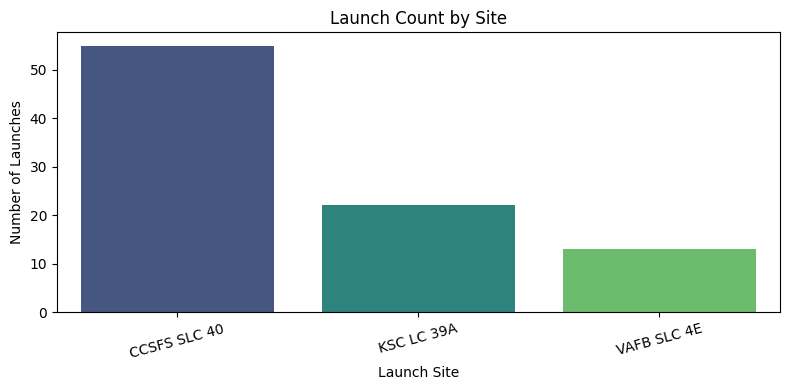

In [16]:
# ------------------------------------------------------------------
# Launch site frequency
# ------------------------------------------------------------------
site_counts = df['LaunchSite'].value_counts()
print(site_counts)

# Visualise
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(x=site_counts.index, y=site_counts.values, palette="viridis")
plt.title('Launch Count by Site')
plt.ylabel('Number of Launches')
plt.xlabel('Launch Site')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


#### Orbit Distribution

Different orbits impose different delta-v requirements on the first stage, directly affecting the feasibility of recovery.


Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
ES-L1     1
HEO       1
SO        1
GEO       1
Name: count, dtype: int64


C:\Users\MG47\AppData\Local\Temp\ipykernel_18048\1239553314.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orbit_counts.index, y=orbit_counts.values, palette="magma")


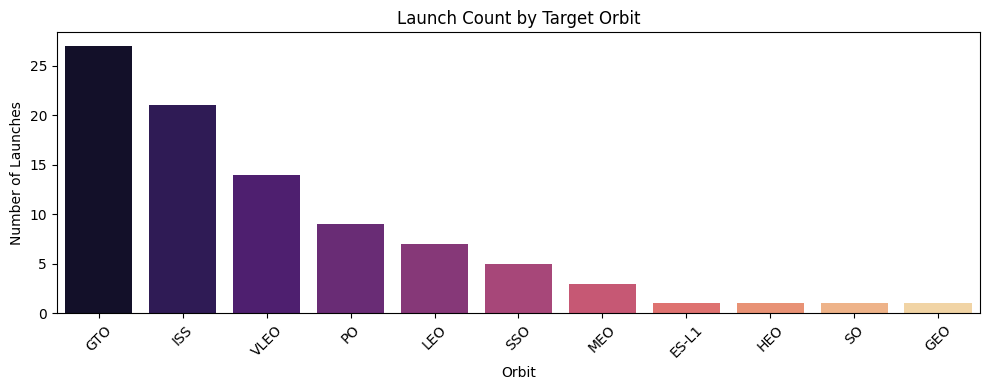

In [17]:
# ------------------------------------------------------------------
# Orbit frequency
# ------------------------------------------------------------------
orbit_counts = df['Orbit'].value_counts()
print(orbit_counts)

plt.figure(figsize=(10, 4))
sns.barplot(x=orbit_counts.index, y=orbit_counts.values, palette="magma")
plt.title('Launch Count by Target Orbit')
plt.ylabel('Number of Launches')
plt.xlabel('Orbit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Landing Outcome Distribution

The `Outcome` column encodes both **success/failure** and **landing type** (Ocean, RTLS, ASDS). We inspect the raw distribution before binarisation.


Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64


C:\Users\MG47\AppData\Local\Temp\ipykernel_18048\2870994937.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=landing_outcomes.index, y=landing_outcomes.values, palette="coolwarm")


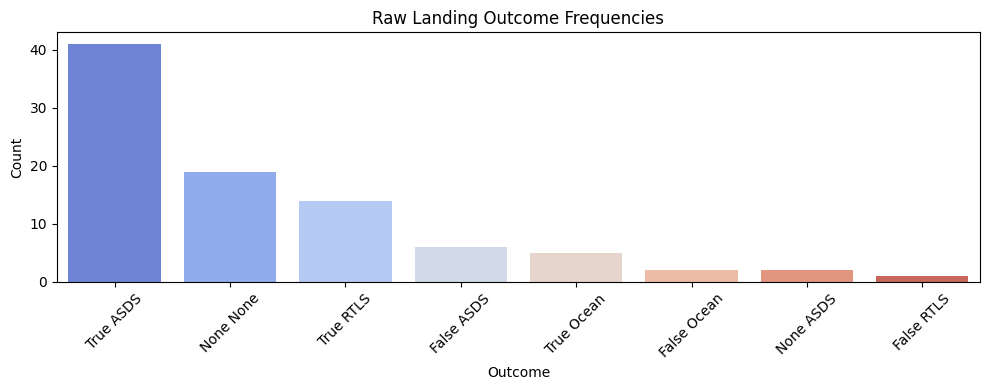

In [18]:
# ------------------------------------------------------------------
# Raw landing outcome frequencies
# ------------------------------------------------------------------
landing_outcomes = df['Outcome'].value_counts()
print(landing_outcomes)

plt.figure(figsize=(10, 4))
sns.barplot(x=landing_outcomes.index, y=landing_outcomes.values, palette="coolwarm")
plt.title('Raw Landing Outcome Frequencies')
plt.ylabel('Count')
plt.xlabel('Outcome')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3.5 Label Engineering — Binary Classification Target

We convert the composite `Outcome` string into a binary `Class` variable:

| Raw Outcome | Interpretation | `Class` |
|---|---|---|
| `True Ocean` / `True RTLS` / `True ASDS` | Successful landing | **1** |
| `False Ocean` / `False RTLS` / `False ASDS` | Failed landing attempt | **0** |
| `None ASDS` / `None None` | No landing attempted / failure | **0** |

This label will serve as the **dependent variable** for all downstream supervised-learning models.


In [19]:
# ------------------------------------------------------------------
# Define bad (unsuccessful) outcome set
# ------------------------------------------------------------------
# Indices of unsuccessful outcomes in the value_counts() ordering
bad_outcomes = set(landing_outcomes.keys()[[1, 3, 5, 6, 7]])
print("Bad outcomes (Class = 0):")
for o in bad_outcomes:
    print(f"  - {o}")

# ------------------------------------------------------------------
# Engineer binary label
# ------------------------------------------------------------------
df['Class'] = df['Outcome'].apply(lambda x: 0 if x in bad_outcomes else 1)

print("\n=== Label Distribution ===")
print(df['Class'].value_counts())
print(f"\nOverall success rate: {df['Class'].mean():.2%}")

df[['Outcome', 'Class']].head(10)


Bad outcomes (Class = 0):
  - False ASDS
  - None None
  - None ASDS
  - False RTLS
  - False Ocean

=== Label Distribution ===
Class
1    60
0    30
Name: count, dtype: int64

Overall success rate: 66.67%


,Outcome,Class
4,None None,0
5,None None,0
6,None None,0
7,False Ocean,0
8,None None,0
9,None None,0
10,True Ocean,1
11,True Ocean,1
12,None None,0
13,None None,0


### 3.6 Data-Type Inspection

We verify that numerical and categorical columns have appropriate dtypes. This step prevents silent type-casting bugs during modeling.


In [20]:
# ------------------------------------------------------------------
# Dtype audit
# ------------------------------------------------------------------
print("=== COLUMN DATA TYPES ===")
print(df.dtypes)

# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nNumerical columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


=== COLUMN DATA TYPES ===
FlightNumber        int64
Date               object
BoosterVersion        str
PayloadMass       float64
Orbit                 str
LaunchSite            str
Outcome               str
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad            str
Block             float64
ReusedCount         int64
Serial                str
Longitude         float64
Latitude          float64
Class               int64
dtype: object

Numerical columns (8): ['FlightNumber', 'PayloadMass', 'Flights', 'Block', 'ReusedCount', 'Longitude', 'Latitude', 'Class']
Categorical columns (10): ['Date', 'BoosterVersion', 'Orbit', 'LaunchSite', 'Outcome', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Serial']


### 3.7 Final Quality Check & Export

We perform a last-pass inspection and export the cleaned dataset to CSV for the EDA and modeling notebooks.


In [21]:
# ------------------------------------------------------------------
# Final statistical summary
# ------------------------------------------------------------------
print("=== FINAL DATASET SUMMARY ===")
print(f"Shape: {df.shape}")
print(f"Missing values per column:\n{df.isnull().sum()}")
print("\n=== NUMERIC SUMMARY ===")
df.describe()


=== FINAL DATASET SUMMARY ===
Shape: (90, 18)
Missing values per column:
FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
Class              0
dtype: int64

=== NUMERIC SUMMARY ===


,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Longitude,Latitude,Class
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,45.500000,6123.547647,1.788889,3.500000,3.188889,-86.366477,29.449963,0.666667
std,26.124701,4732.115291,1.213172,1.595288,4.194417,14.149518,2.141306,0.474045
min,1.000000,350.000000,1.000000,1.000000,0.000000,-120.610829,28.561857,0.000000
25%,23.250000,2510.750000,1.000000,2.000000,0.000000,-80.603956,28.561857,0.000000
50%,45.500000,4701.500000,1.000000,4.000000,1.000000,-80.577366,28.561857,1.000000
75%,67.750000,8912.750000,2.000000,5.000000,4.000000,-80.577366,28.608058,1.000000
max,90.000000,15600.000000,6.000000,5.000000,13.000000,-80.577366,34.632093,1.000000


In [22]:
# ------------------------------------------------------------------
# Persist cleaned dataset
# ------------------------------------------------------------------
df.to_csv('../data/processed/01_spacex_dataset_cleaned.csv', index=False)
print("Saved: ../data/processed/01_spacex_dataset_cleaned.csv")
print("   Ready for EDA, SQL analysis, and machine learning pipelines.")


Saved: ../data/processed/01_spacex_dataset_cleaned.csv
   Ready for EDA, SQL analysis, and machine learning pipelines.


---

## Conclusion

### What We Accomplished

1. **API Data Collection** — Queried the SpaceX REST API, resolved foreign keys into 15+ enriched features (booster, payload, orbit, landing metadata, coordinates).
2. **Web Scraping** — Extracted a parallel historical dataset from Wikipedia via `BeautifulSoup`, handling noisy HTML annotations and inconsistent formatting.
3. **Data Cleaning** — Filtered to Falcon 9 only, imputed missing payload masses, and audited data types.
4. **Label Engineering** — Created the binary `Class` target variable from composite landing-outcome strings, yielding a ~67% success rate in the training window.
5. **Quality Assurance** — Performed rapid EDA on launch sites, orbits, and outcome distributions to validate data integrity.

### Key Observations

- **CCAFS SLC-40** is the most frequently used launch site, followed by **KSC LC-39A** and **VAFB SLC-4E**.
- **GTO** and **ISS/LEO** orbits dominate the mission manifest.
- Landing success improved significantly over time as SpaceX iterated on booster recovery technology (visible in the temporal trend of `Class`).

### Next Steps

The cleaned dataset (`01_spacex_dataset_cleaned.csv`) is now ready for:

- **Notebook 02** — Deep exploratory data analysis, SQL querying, and advanced visualisations (Seaborn, Plotly).
- **Notebook 03** — Interactive geospatial mapping (Folium) of launch sites and landing zones.
- **Notebook 04** — Feature engineering, model training (Logistic Regression, SVM, Decision Trees, XGBoost), and performance evaluation.

---

